<a href="https://colab.research.google.com/github/Sairaj0531/ITA-Assignments-Sairaj-/blob/main/Sairaj_Assignment_ITA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload the 'KDDTest+.arff.zip' file:


Saving KDDTest+.arff.zip to KDDTest+.arff.zip


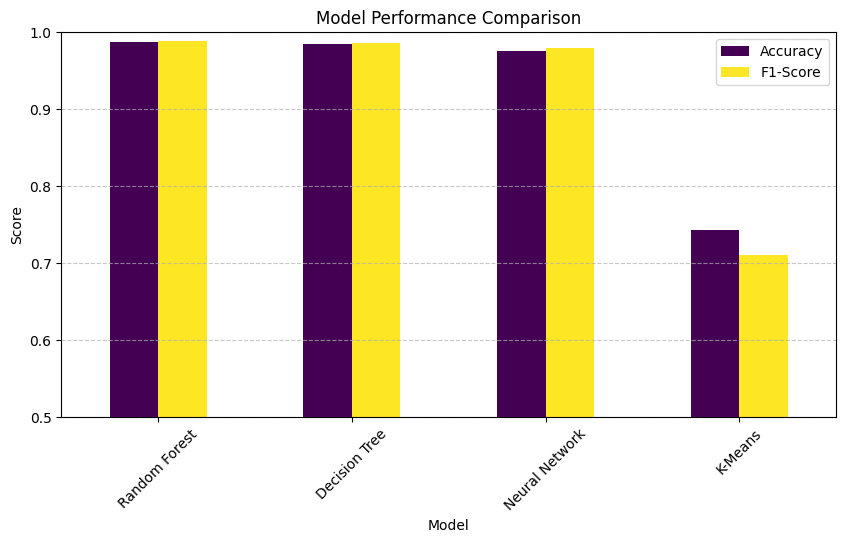

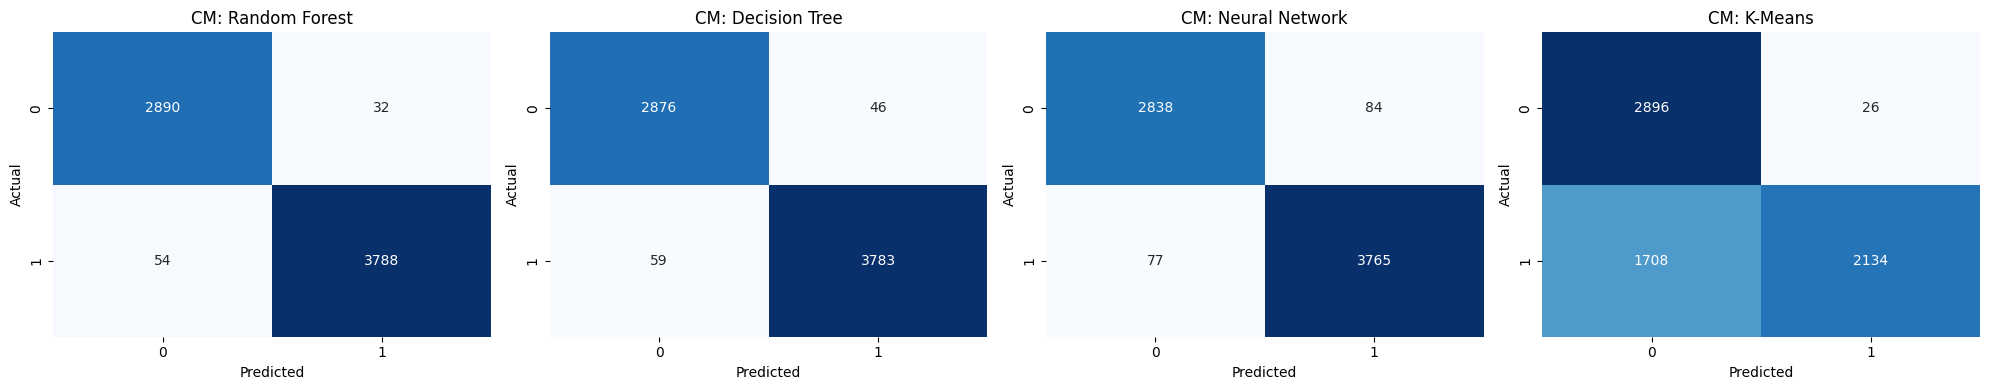


--- Final Analysis Results ---
         Model  Accuracy  Precision   Recall  F1-Score
 Random Forest  0.987286   0.991623 0.985945  0.988776
 Decision Tree  0.984477   0.987986 0.984643  0.986312
Neural Network  0.976198   0.978176 0.979958  0.979066
       K-Means  0.743643   0.987963 0.555440  0.711096

Top 5 Contributing Features (Random Forest):
src_bytes                 0.129760
dst_bytes                 0.106297
service_http              0.066365
dst_host_rerror_rate      0.060227
dst_host_diff_srv_rate    0.057018
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# 1. Upload File
print("Please upload the 'KDDTest+.arff.zip' file:")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

# 2. Extraction
extract_path = 'nsl_kdd_data'
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

arff_file = os.path.join(extract_path, 'KDDTest+.arff')

# 3. Parse ARFF to DataFrame
data, columns = [], []
with open(arff_file, 'r') as f:
    for line in f:
        if line.lower().startswith('@attribute'):
            col = line.split("'")[1]
            columns.append(col)
        elif not line.startswith('@') and line.strip():
            data.append(line.strip().split(','))

df = pd.DataFrame(data, columns=columns)

# 4. Preprocessing
for col in df.columns:
    if col not in ['protocol_type', 'service', 'flag', 'class']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['target'] = df['class'].apply(lambda x: 1 if x == 'anomaly' else 0)
X_raw = pd.get_dummies(df.drop(['class', 'target'], axis=1), columns=['protocol_type', 'service', 'flag'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 5. Model Training & Data Collection
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = []
all_preds = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    all_preds[name] = preds
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='binary')
    results.append([name, acc, prec, rec, f1])

# Unsupervised (K-Means)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_train)
k_clusters = kmeans.predict(X_test)
mapping = {i: y_test[k_clusters == i].mode()[0] for i in range(2)}
y_pred_k = np.array([mapping[c] for c in k_clusters])
all_preds["K-Means"] = y_pred_k
prec_k, rec_k, f1_k, _ = precision_recall_fscore_support(y_test, y_pred_k, average='binary')
results.append(["K-Means", accuracy_score(y_test, y_pred_k), prec_k, rec_k, f1_k])

# 6. VISUALIZATION
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

# A. Comparison Graph
results_df.set_index('Model')[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# B. Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, (name, preds) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f'CM: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# C. Final Conclusion Table
print("\n--- Final Analysis Results ---")
print(results_df.to_string(index=False))

# D. Feature Contribution
importances = pd.Series(models["Random Forest"].feature_importances_, index=X_raw.columns).sort_values(ascending=False)
print("\nTop 5 Contributing Features (Random Forest):")
print(importances.head(5))